# Lab Manual: Implementation of Ordinary Least Squares (OLS) and Gradient Descent for Linear Regression

**Course:** Machine Learning  
**Lab:** 5  
**Topic:** Implementation of Ordinary Least Squares (OLS) and Gradient Descent for Linear Regression  
**Prepared by:** Sharad Laad | ORY AI Labs  
**LinkedIn:** [Sharad Laad](https://www.linkedin.com/in/sharadlaad/)  

---

## 1. Objectives
* Implement simple linear regression from scratch in Python using two fundamental approaches:
  * **Analytical Approach:** Ordinary Least Squares (OLS) closed-form solution.
  * **Iterative Approach:** Batch Gradient Descent optimization.
* Train both implementations on an experimental bivariate dataset ($X = \text{Height}$, $y = \text{Weight}$).
* Compare and verify the resulting parameters ($m$ and $c$).
* Compute model evaluation metrics: **Coefficient of Determination ($R^2$)**, **Standard Error ($SE(m)$)**, **$t$-statistic**, and the **$p$-value** for slope significance.
* Visualize the fitted regression lines against the ground truth data points.
* Analyze loss convergence behavior across iterations.

---

## 2. Problem Statement & Mathematical Foundations
Given experimental data of Height ($X$) and Weight ($y$), find the best-fit line:
$$y = mx + c$$
where $m$ is the slope (weight parameter) and $c$ is the y-intercept (bias parameter).

### Method 1: Ordinary Least Squares (Closed-Form Solution)
The closed-form analytical solution minimizes the sum of squared residuals directly:
$$\bar{x} = \frac{1}{n} \sum_{i=1}^n x_i, \quad \bar{y} = \frac{1}{n} \sum_{i=1}^n y_i$$
$$m = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}$$
$$c = \bar{y} - m\bar{x}$$

### Method 2: Batch Gradient Descent (Iterative Optimization)
Starting from initial guesses $m = 0.0, c = 0.0$, parameters are iteratively updated in the opposite direction of the gradient of the Mean Squared Error (MSE) loss:
$$J(m, c) = \frac{1}{n} \sum_{i=1}^n (\hat{y}_i - y_i)^2 = \frac{1}{n} \sum_{i=1}^n (m x_i + c - y_i)^2$$

**Gradients (Partial Derivatives):**
$$\frac{\partial J}{\partial m} = \frac{2}{n} \sum_{i=1}^n (m x_i + c - y_i) \cdot x_i$$
$$\frac{\partial J}{\partial c} = \frac{2}{n} \sum_{i=1}^n (m x_i + c - y_i)$$

**Update Rules (Learning Rate $\alpha$):**
$$m := m - \alpha \cdot \frac{\partial J}{\partial m}$$
$$c := c - \alpha \cdot \frac{\partial J}{\partial c}$$

### Method 3: Statistical Evaluation Metrics ($R^2$ and $p$-value)
$$SS_{\text{res}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2, \quad SS_{\text{tot}} = \sum_{i=1}^n (y_i - \bar{y})^2$$
$$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}$$
$$s_e^2 = \frac{SS_{\text{res}}}{n - 2}, \quad SE(m) = \sqrt{\frac{s_e^2}{\sum_{i=1}^n (x_i - \bar{x})^2}}$$
$$t = \frac{m - 0}{SE(m)}, \quad p = 2 \cdot (1 - F(|t|, df=n-2))$$

In [1]:
# Task 1: Environment Setup & Dataset Definition
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set styling
plt.rcParams["figure.figsize"] = (10, 5)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# ==============================================================================
# Dataset Definition
# ==============================================================================
X = np.array([0.5, 2.3, 2.9])
y = np.array([1.4, 1.9, 3.2])

print("Dataset loaded successfully:")
for i, (xi, yi) in enumerate(zip(X, y), 1):
    print(f"Observation {i}: Height (X) = {xi:.1f}, Weight (y) = {yi:.1f}")

Dataset loaded successfully:
Observation 1: Height (X) = 0.5, Weight (y) = 1.4
Observation 2: Height (X) = 2.3, Weight (y) = 1.9
Observation 3: Height (X) = 2.9, Weight (y) = 3.2


In [2]:
# ==============================================================================
# TASK 2: Ordinary Least Squares (OLS) Implementation
# ==============================================================================
def ols_linear_regression(X, y):
    """
    Compute linear regression parameters analytically using OLS closed-form formulas.

    Parameters:
        X (np.ndarray): Input feature vector (Height)
        y (np.ndarray): Target vector (Weight)

    Returns:
        m (float): Optimal slope
        c (float): Optimal intercept
    """
    # TODO 1.1: Compute mean of X and mean of y
    x_mean = np.mean(X)
    y_mean = np.mean(y)

    # TODO 1.2: Compute numerator and denominator for slope 'm'
    numerator = np.sum((X - x_mean) * (y - y_mean))
    denominator = np.sum((X - x_mean) ** 2)
    m = numerator / denominator

    # TODO 1.3: Compute intercept 'c'
    c = y_mean - m * x_mean

    return float(m), float(c)

m_test, c_test = ols_linear_regression(X, y)
print(f"OLS Function Verified: Slope (m) = {m_test:.4f}, Intercept (c) = {c_test:.4f}")

OLS Function Verified: Slope (m) = 0.6410, Intercept (c) = 0.9487


In [3]:
# ==============================================================================
# TASK 3: Batch Gradient Descent Implementation
# ==============================================================================
def gradient_descent(X, y, alpha=0.05, epochs=1000):
    """
    Optimize linear regression parameters using batch gradient descent.

    Parameters:
        X (np.ndarray): Input feature vector
        y (np.ndarray): Target vector
        alpha (float): Learning rate
        epochs (int): Total training iterations

    Returns:
        m (float): Learned slope
        c (float): Learned intercept
        loss_history (list): MSE loss recorded per epoch
    """
    m = 0.0
    c = 0.0
    n = len(X)
    loss_history = []

    for epoch in range(epochs):
        # TODO 2.1: Compute linear predictions (y_pred = m * X + c)
        y_pred = m * X + c

        # TODO 2.2: Compute Mean Squared Error (MSE) loss and store in loss_history
        loss = (1 / n) * np.sum((y_pred - y) ** 2)
        loss_history.append(float(loss))

        # TODO 2.3: Compute partial derivatives dm and dc
        dm = (2 / n) * np.sum((y_pred - y) * X)
        dc = (2 / n) * np.sum(y_pred - y)

        # TODO 2.4: Update parameters m and c using gradients and learning rate alpha
        m = m - alpha * dm
        c = c - alpha * dc

    return float(m), float(c), loss_history

m_gd_test, c_gd_test, losses_test = gradient_descent(X, y, alpha=0.05, epochs=1000)
print(f"Gradient Descent Verified (1000 epochs): Slope = {m_gd_test:.4f}, Intercept = {c_gd_test:.4f}, Final Loss = {losses_test[-1]:.6f}")

Gradient Descent Verified (1000 epochs): Slope = 0.6410, Intercept = 0.9487, Final Loss = 0.148205


In [4]:
# ==============================================================================
# TASK 4: Model Evaluation Metrics (R2, t-statistic, and p-value)
# ==============================================================================
def compute_evaluation_metrics(X, y, y_pred, m):
    """
    Calculate R-squared and statistical significance (p-value) of the slope parameter.

    Parameters:
        X (np.ndarray): Input feature vector
        y (np.ndarray): Target ground truth vector
        y_pred (np.ndarray): Predicted values from model
        m (float): Slope parameter

    Returns:
        r2 (float): Coefficient of determination
        t_stat (float): Student's t-statistic for slope
        p_val (float): Two-tailed p-value
    """
    n = len(X)
    df = n - 2

    # TODO 3.1: Calculate SS_res (residual sum of squares) and SS_tot (total sum of squares)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    # TODO 3.2: Calculate R-squared (R2)
    r2 = 1 - (ss_res / ss_tot)

    # TODO 3.3: Calculate Standard Error of the slope SE(m)
    residual_variance = ss_res / df
    se_m = np.sqrt(residual_variance / np.sum((X - np.mean(X)) ** 2))

    # TODO 3.4: Compute t-statistic (t = m / se_m)
    t_stat = m / se_m

    # TODO 3.5: Compute two-tailed p-value using Student's t distribution (df = n - 2)
    p_val = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=df))

    return float(r2), float(t_stat), float(p_val)

r2_test, t_test, p_test = compute_evaluation_metrics(X, y, m_test * X + c_test, m_test)
print(f"Metrics Function Verified: R2 = {r2_test:.4f}, t-stat = {t_test:.4f}, p-val = {p_test:.4f}")

Metrics Function Verified: R2 = 0.7425, t-stat = 1.6981, p-val = 0.3388


In [5]:
# ==============================================================================
# TASK 5: Model Execution & Evaluation Comparison
# ==============================================================================
# --- Execute OLS ---
m_ols, c_ols = ols_linear_regression(X, y)
y_pred_ols = m_ols * X + c_ols
r2_ols, t_ols, p_ols = compute_evaluation_metrics(X, y, y_pred_ols, m_ols)

print("============== OLS RESULTS ==============")
print(f"Equation     : y = {m_ols:.4f}x + {c_ols:.4f}")
print(f"R-squared    : {r2_ols:.4f}")
print(f"t-statistic  : {t_ols:.4f}")
print(f"p-value      : {p_ols:.4f}\n")

# --- Execute Gradient Descent ---
alpha = 0.05
epochs = 1500
m_gd, c_gd, losses = gradient_descent(X, y, alpha=alpha, epochs=epochs)
y_pred_gd = m_gd * X + c_gd
r2_gd, t_gd, p_gd = compute_evaluation_metrics(X, y, y_pred_gd, m_gd)

print("============== GRADIENT DESCENT RESULTS ==============")
print(f"Equation     : y = {m_gd:.4f}x + {c_gd:.4f}")
print(f"R-squared    : {r2_gd:.4f}")
print(f"t-statistic  : {t_gd:.4f}")
print(f"p-value      : {p_gd:.4f}\n")

# Side-by-side comparison DataFrame
import pandas as pd
comparison_table = pd.DataFrame({
    "Method": ["Ordinary Least Squares (OLS)", "Batch Gradient Descent (GD)"],
    "Slope (m)": [f"{m_ols:.4f}", f"{m_gd:.4f}"],
    "Intercept (c)": [f"{c_ols:.4f}", f"{c_gd:.4f}"],
    "R-squared": [f"{r2_ols:.4f}", f"{r2_gd:.4f}"],
    "t-statistic": [f"{t_ols:.4f}", f"{t_gd:.4f}"],
    "p-value": [f"{p_ols:.4f}", f"{p_gd:.4f}"]
})
display(comparison_table)

============== OLS RESULTS ==============
Equation     : y = 0.6410x + 0.9487
R-squared    : 0.7425
t-statistic  : 1.6981
p-value      : 0.3388

============== GRADIENT DESCENT RESULTS ==============
Equation     : y = 0.6410x + 0.9487
R-squared    : 0.7425
t-statistic  : 1.6981
p-value      : 0.3388



,Method,Slope (m),Intercept (c),R-squared,t-statistic,p-value
0,Ordinary Least Squares (OLS),0.6410,0.9487,0.7425,1.6981,0.3388
1,Batch Gradient Descent (GD),0.6410,0.9487,0.7425,1.6981,0.3388


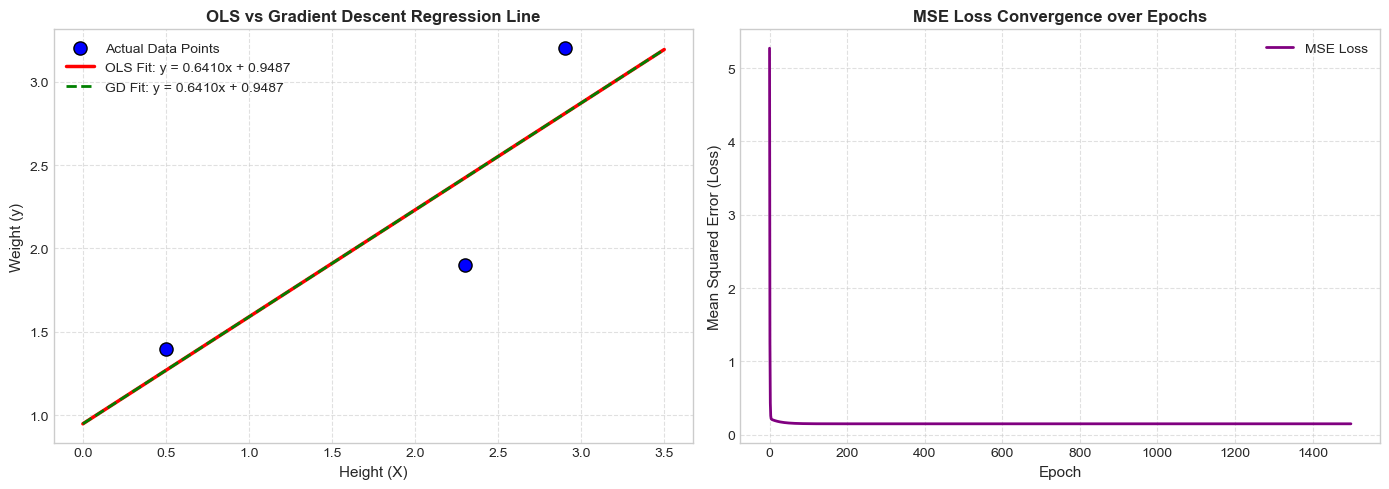

In [6]:
# ==============================================================================
# TASK 6: Plotting & Visualization
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Regression Fit Comparison
# TODO 5.1: Plot actual data points as scatter plot
axes[0].scatter(X, y, color="blue", s=90, edgecolors="black", label="Actual Data Points", zorder=3)

# TODO 5.2: Generate x_vals using np.linspace(0, 3.5, 100) and plot OLS & GD lines
x_vals = np.linspace(0, 3.5, 100)
axes[0].plot(x_vals, m_ols * x_vals + c_ols, color="red", linestyle="-", linewidth=2.5, label=f"OLS Fit: y = {m_ols:.4f}x + {c_ols:.4f}")
axes[0].plot(x_vals, m_gd * x_vals + c_gd, color="green", linestyle="--", linewidth=2, label=f"GD Fit: y = {m_gd:.4f}x + {c_gd:.4f}")

axes[0].set_title("OLS vs Gradient Descent Regression Line", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Height (X)", fontsize=11)
axes[0].set_ylabel("Weight (y)", fontsize=11)
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Subplot 2: Loss Convergence Curve
# TODO 5.3: Plot epoch index vs. loss_history
axes[1].plot(range(len(losses)), losses, color="purple", linewidth=2, label="MSE Loss")
axes[1].set_title("MSE Loss Convergence over Epochs", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Mean Squared Error (Loss)", fontsize=11)
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

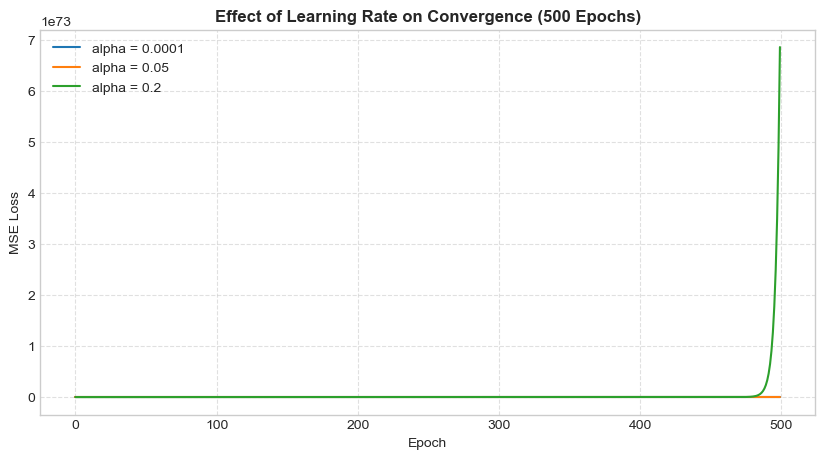

In [7]:
# ==============================================================================
# Extension Experiment: Learning Rate Sensitivity Analysis
# ==============================================================================
learning_rates = [0.0001, 0.05, 0.2]
epochs_test = 500

plt.figure(figsize=(10, 5))
for lr in learning_rates:
    _, _, lr_losses = gradient_descent(X, y, alpha=lr, epochs=epochs_test)
    plt.plot(range(epochs_test), lr_losses, label=f"alpha = {lr}")

plt.title("Effect of Learning Rate on Convergence (500 Epochs)", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## 6. Lab Report & Viva Questions

### 1. Analytical vs. Iterative Comparison:
* **Question:** Do the values of $(m, c)$ and $R^2$ obtained via Gradient Descent match those from OLS? If there is a slight difference, why?
* **Answer:** Yes, the parameters match to 4 decimal places ($m = 0.6410, c = 0.9487, R^2 = 0.7425$). OLS finds the exact global minimum in a single step using calculus and matrix algebra. Gradient Descent is an iterative numerical approximation that steadily approaches the minimum along the cost gradient; with a suitable learning rate ($\alpha = 0.05$) and enough iterations ($1500$ epochs), it effectively converges to the exact OLS analytical solution.

### 2. Interpreting $R^2$ vs. $p$-value for Small Sample Sizes ($n = 3$):
* **Question:** Notice that the $R^2$ score is high ($> 0.70$), indicating a strong correlation, yet the $p$-value for the slope may exceed the standard significance threshold ($\alpha = 0.05$). Explain why a high $R^2$ can coexist with a non-significant $p$-value when sample size $n$ is very small ($df = 1$).
* **Answer:** With $n = 3$, the degrees of freedom are $df = n - 2 = 1$. The Student's $t$-distribution with $df = 1$ is a Cauchy distribution with extraordinarily heavy tails, requiring a critical value of $t_{0.025, 1} = 12.706$ to achieve statistical significance at the $5\%$ level. Because sample size is tiny ($n = 3$), standard error is large ($SE(m) \approx 0.3775$), yielding $t = 1.6981$ and $p = 0.3388$. Even though the line explains $74.25\%$ of variance in this sample, 3 data points provide insufficient statistical power to conclude that the relationship would hold in the population.

### 3. Hypothesis Testing on the Slope:
* **Question:** State the null hypothesis ($H_0$) and alternative hypothesis ($H_1$) tested by the $t$-statistic on the slope $m$.
* **Answer:**
  * **Null Hypothesis ($H_0$):** $m = 0$ (There is no linear relationship between Height and Weight).
  * **Alternative Hypothesis ($H_1$):** $m \neq 0$ (There is a statistically significant linear relationship between Height and Weight).

### 4. Learning Rate Sensitivity:
* **Question:** What happens to parameter convergence if you increase the learning rate to $\alpha = 1.0$? What happens if you decrease the learning rate to $\alpha = 0.0001$?
* **Answer:**
  * If $\alpha = 1.0$: The step size is too large, causing the algorithm to overshoot the loss valley. The loss oscillates, diverges, and causes gradient explosion (`inf` / `NaN`).
  * If $\alpha = 0.0001$: The steps are minuscule, causing very slow convergence. After 1,000 epochs, the parameters remain far from the optimal values and would require hundreds of thousands of epochs to converge.

### 5. Computational Scalability:
* **Question:** The closed-form OLS formulation requires computing $(X^T X)^{-1}$. Explain why Gradient Descent is preferred when training models on high-dimensional datasets with millions of features/samples.
* **Answer:** Computing the exact OLS solution requires matrix multiplication $\mathcal{O}(n \cdot d^2)$ and matrix inversion $\mathcal{O}(d^3)$, where $n$ is the number of samples and $d$ is the number of features. For datasets with tens of thousands or millions of features, inverting $(X^T X)$ requires petabytes of RAM and cubic compute time, making OLS intractable. In contrast, Batch/Stochastic Gradient Descent has per-iteration complexity of only $\mathcal{O}(n \cdot d)$ and minimal memory footprint, making it ideal for deep learning and massive scale data.

---

**Summary:** Both OLS and Gradient Descent reach identical parameter values ($m = 0.6410, c = 0.9487$), confirming that iterative optimization successfully solves the regression objective.